In [1]:
import pandas as pd
import numpy as np

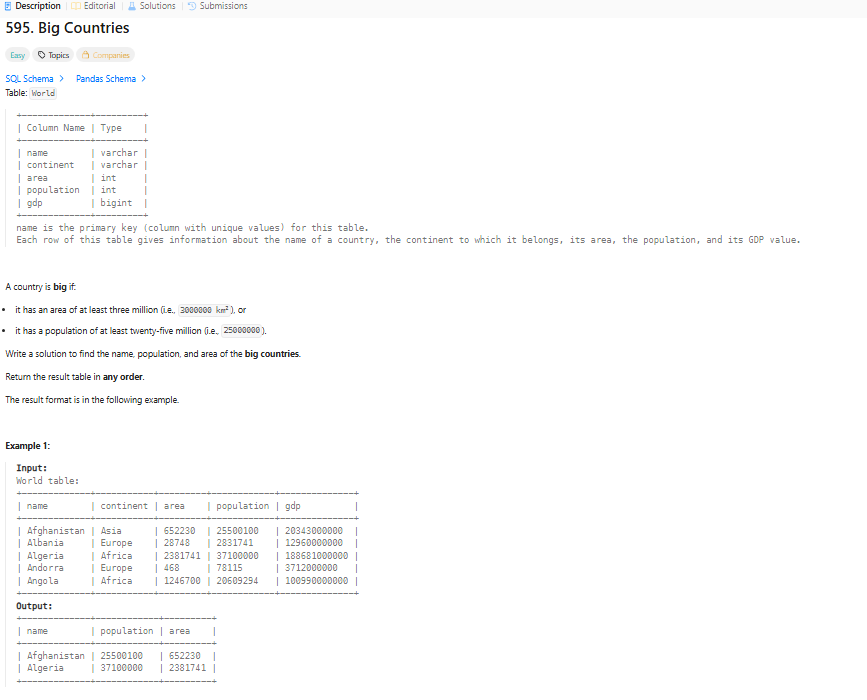

In [2]:
data = [['Afghanistan', 'Asia', 652230, 25500100, 20343000000], ['Albania', 'Europe', 28748, 2831741, 12960000000], ['Algeria', 'Africa', 2381741, 37100000, 188681000000], ['Andorra', 'Europe', 468, 78115, 3712000000], ['Angola', 'Africa', 1246700, 20609294, 100990000000]]
world = pd.DataFrame(data, columns=['name', 'continent', 'area', 'population', 'gdp']).astype({'name':'object', 'continent':'object', 'area':'Int64', 'population':'Int64', 'gdp':'Int64'})

In [3]:
world

,name,continent,area,population,gdp
0,Afghanistan,Asia,652230,25500100,20343000000
1,Albania,Europe,28748,2831741,12960000000
2,Algeria,Africa,2381741,37100000,188681000000
3,Andorra,Europe,468,78115,3712000000
4,Angola,Africa,1246700,20609294,100990000000


In [4]:

def big_countries(world: pd.DataFrame) -> pd.DataFrame:
    big_area=3000000 
    high_pop=25000000
    return world[(world['area']>=big_area)| (world['population']>=high_pop)][['name', 'population', 'area']]

In [5]:
big_countries(world)

,name,population,area
0,Afghanistan,25500100,652230
2,Algeria,37100000,2381741


In [6]:
data = [['0', 'Y', 'N'], ['1', 'Y', 'Y'], ['2', 'N', 'Y'], ['3', 'Y', 'Y'], ['4', 'N', 'N']]
products = pd.DataFrame(data, columns=['product_id', 'low_fats', 'recyclable']).astype({'product_id':'int64', 'low_fats':'category', 'recyclable':'category'})

In [7]:
def find_products(products: pd.DataFrame) -> pd.DataFrame:
    return products[(products['low_fats']=='Y') & (products['recyclable']=='Y')][['product_id']]

In [8]:
find_products(products)

,product_id
1,1
3,3


Write a solution to find all customers who never order anything.

Return the result table in any order.

The result format is in the following example.

In [9]:
data = [[1, 'Joe'], [2, 'Henry'], [3, 'Sam'], [4, 'Max']]
customers = pd.DataFrame(data, columns=['id', 'name']).astype({'id':'Int64', 'name':'object'})
data = [[1, 3], [2, 1]]
orders = pd.DataFrame(data, columns=['id', 'customerId']).astype({'id':'Int64', 'customerId':'Int64'})

In [10]:
def find_customers(customers: pd.DataFrame, orders: pd.DataFrame) -> pd.DataFrame:
    return customers[~customers['id'].isin(orders['customerId'])][['name']].rename(columns={'name':'Customers'})

In [11]:
find_customers(customers, orders)

,Customers
1,Henry
3,Max


Write a solution to find all the authors that viewed at least one of their own articles.

Return the result table sorted by id in ascending order.

The result format is in the following example.

In [12]:
data = [[1, 3, 5, '2019-08-01'], [1, 3, 6, '2019-08-02'], [2, 7, 7, '2019-08-01'], [2, 7, 6, '2019-08-02'], [4, 7, 1, '2019-07-22'], [3, 4, 4, '2019-07-21'], [3, 4, 4, '2019-07-21']]
views = pd.DataFrame(data, columns=['article_id', 'author_id', 'viewer_id', 'view_date']).astype({'article_id':'Int64', 'author_id':'Int64', 'viewer_id':'Int64', 'view_date':'datetime64[ns]'})

In [13]:
# Authors who viewed at least one of their own articles
def article_views(views: pd.DataFrame) -> pd.DataFrame:
    return (
        views.loc[views["author_id"] == views["viewer_id"], ["author_id"]]
        .drop_duplicates()
        .sort_values("author_id")
        .reset_index(drop=True)
    )

article_views(views)

,author_id
0,4
1,7


Write a solution to find the IDs of the invalid tweets. The tweet is invalid if the number of characters used in the content of the tweet is strictly greater than 15.

In [14]:
data = [[1, 'Let us Code'], [2, 'More than fifteen chars are here!']]
tweets = pd.DataFrame(data, columns=['tweet_id', 'content']).astype({'tweet_id':'Int64', 'content':'object'})

In [15]:
tweets[tweets['content'].str.len()>15][['tweet_id']]

,tweet_id
1,2


### Write a solution to calculate the bonus of each employee. The bonus of an employee is 100% of their salary if the ID of the employee is an odd number 
### and the employee's name does not start with the character 'M'. The bonus of an employee is 0 otherwise.

In [16]:
data = [[2, 'Meir', 3000], [3, 'Michael', 3800], [7, 'Addilyn', 7400], [8, 'Juan', 6100], [9, 'Kannon', 7700]]
employees = pd.DataFrame(data, columns=['employee_id', 'name', 'salary']).astype({'employee_id':'int64', 'name':'object', 'salary':'int64'})
employees

,employee_id,name,salary
0,2,Meir,3000
1,3,Michael,3800
2,7,Addilyn,7400
3,8,Juan,6100
4,9,Kannon,7700


In [17]:
employees['bonus']=employees.apply(lambda x : x['salary'] if ((~x['name'].startswith('M')) and ((x['employee_id'] %2) != 0)) else 0,axis=1)

C:\Users\jhaki\AppData\Local\Temp\ipykernel_6132\4032142375.py:1: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  employees['bonus']=employees.apply(lambda x : x['salary'] if ((~x['name'].startswith('M')) and ((x['employee_id'] %2) != 0)) else 0,axis=1)


In [18]:
employees[['employee_id','bonus']]

,employee_id,bonus
0,2,0
1,3,3800
2,7,7400
3,8,0
4,9,7700


Write a solution to fix the names so that only the first character is uppercase and the rest are lowercase.

Return the result table ordered by user_id.

In [110]:
data = [[1, 'aLice'], [2, 'bOB']]
users = pd.DataFrame(data, columns=['user_id', 'name']).astype({'user_id':'Int64', 'name':'object'})
users

,user_id,name
0,1,aLice
1,2,bOB


In [111]:
users['name']=users['name'].apply(lambda x: x.capitalize())
users

,user_id,name
0,1,Alice
1,2,Bob


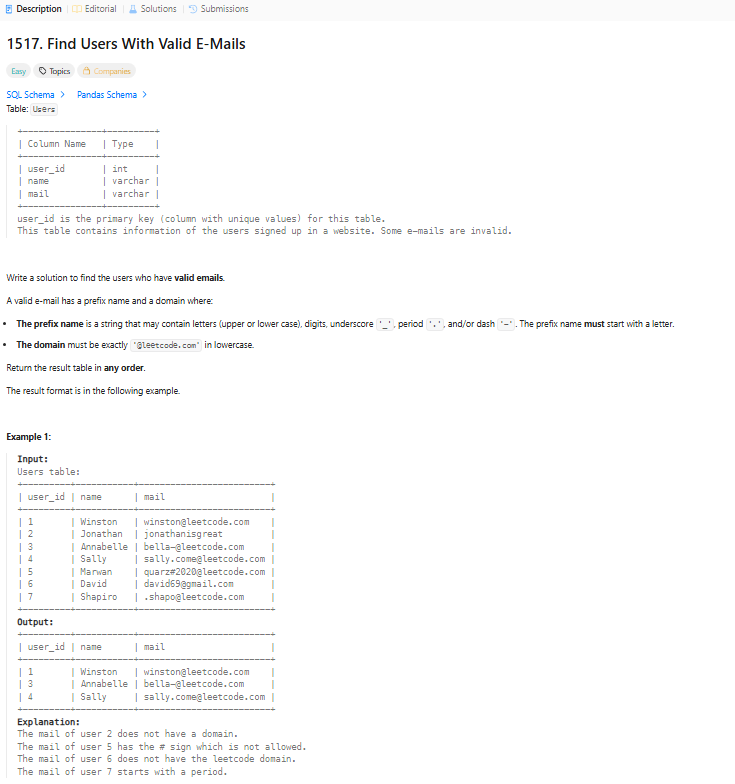

In [21]:
data = [[1, 'Winston', 'winston@leetcode.com'], [2, 'Jonathan', 'jonathanisgreat'], [3, 'Annabelle', 'bella-@leetcode.com'], [4, 'Sally', 'sally.come@leetcode.com'], [5, 'Marwan', 'quarz#2020@leetcode.com'], [6, 'David', 'david69@gmail.com'], [7, 'Shapiro', '.shapo@leetcode.com']]
users = pd.DataFrame(data, columns=['user_id', 'name', 'mail']).astype({'user_id':'int64', 'name':'object', 'mail':'object'})
users

,user_id,name,mail
0,1,Winston,winston@leetcode.com
1,2,Jonathan,jonathanisgreat
2,3,Annabelle,bella-@leetcode.com
3,4,Sally,sally.come@leetcode.com
4,5,Marwan,quarz#2020@leetcode.com
5,6,David,david69@gmail.com
6,7,Shapiro,.shapo@leetcode.com


In [22]:
users.loc[users["mail"].apply(lambda x:(
                                    len(x.split("@"))==2
                                    and x.split("@")[1]=="leetcode.com"
                                    and x[0].isalpha()
                                    and all(ch.isalnum() or ch in "_.-" for ch in x.split("@")[0])) )]

,user_id,name,mail
0,1,Winston,winston@leetcode.com
2,3,Annabelle,bella-@leetcode.com
3,4,Sally,sally.come@leetcode.com


https://towardsdatascience.com/everything-you-need-to-know-about-ranking-with-pandas-aa2ab5921c01/

## Rank

In [23]:
df = pd.DataFrame({
    "name": ["John","Jane","Emily","Lisa","Matt","Jenny","Adam"],
    "current": [92,94,87,82,90,78,84],
    "overall": [184,173,184,201,208,182,185],
    "group":["A","B","C","A","A","C","B"]
})
df

,name,current,overall,group
0,John,92,184,A
1,Jane,94,173,B
2,Emily,87,184,C
3,Lisa,82,201,A
4,Matt,90,208,A
5,Jenny,78,182,C
6,Adam,84,185,B


In [24]:
df["rank_default"] = df["overall"].rank()
df

,name,current,overall,group,rank_default
0,John,92,184,A,3.5
1,Jane,94,173,B,1.0
2,Emily,87,184,C,3.5
3,Lisa,82,201,A,6.0
4,Matt,90,208,A,7.0
5,Jenny,78,182,C,2.0
6,Adam,84,185,B,5.0


In [25]:
df["rank_default_desc"] = df["overall"].rank(ascending=False)
#df = df.sort_values(by="rank_default_desc", ignore_index=True)
df

,name,current,overall,group,rank_default,rank_default_desc
0,John,92,184,A,3.5,4.5
1,Jane,94,173,B,1.0,7.0
2,Emily,87,184,C,3.5,4.5
3,Lisa,82,201,A,6.0,2.0
4,Matt,90,208,A,7.0,1.0
5,Jenny,78,182,C,2.0,6.0
6,Adam,84,185,B,5.0,3.0


In [26]:
df["rank_first"] = df["overall"].rank(method="first", ascending=False)
df["rank_dense"] = df["overall"].rank(method="dense", ascending=False)

df

,name,current,overall,group,rank_default,rank_default_desc,rank_first,rank_dense
0,John,92,184,A,3.5,4.5,4.0,4.0
1,Jane,94,173,B,1.0,7.0,7.0,6.0
2,Emily,87,184,C,3.5,4.5,5.0,4.0
3,Lisa,82,201,A,6.0,2.0,2.0,2.0
4,Matt,90,208,A,7.0,1.0,1.0,1.0
5,Jenny,78,182,C,2.0,6.0,6.0,5.0
6,Adam,84,185,B,5.0,3.0,3.0,3.0


SQL Window FunctionPandas Equivalent

RANK()    : df.groupby('dept')['salary'].rank(method='min')


DENSE_RANK()   :    df.groupby('dept')['salary'].rank(method='dense')


ROW_NUMBER()   :  df.groupby('dept')['salary'].rank(method='first') (or .cumcount() + 1)

### Write a solution to find the patient_id, patient_name, and conditions of the patients who have Type I Diabetes. 
### Type I Diabetes always starts with DIAB1 prefix.

In [27]:
data = [[1, 'Daniel', 'YFEV COUGH'], [2, 'Alice', ''], [3, 'Bob', 'DIAB100 MYOP'], [4, 'George', 'ACNE DIAB100'], [5, 'Alain', 'DIAB201']]
patients = pd.DataFrame(data, columns=['patient_id', 'patient_name', 'conditions']).astype({'patient_id':'int64', 'patient_name':'object', 'conditions':'object'})
patients

,patient_id,patient_name,conditions
0,1,Daniel,YFEV COUGH
1,2,Alice,
2,3,Bob,DIAB100 MYOP
3,4,George,ACNE DIAB100
4,5,Alain,DIAB201


In [28]:
patients.loc[patients['conditions'].apply(lambda x: any(i.startswith('DIAB1') for i in x.split(" ")))]

,patient_id,patient_name,conditions
2,3,Bob,DIAB100 MYOP
3,4,George,ACNE DIAB100


In [112]:
### Nth Highest Salary
### Write a solution to find the nth highest distinct salary from the Employee table. If there are less than n distinct salaries, return null.

data = [[1, 100], [2, 600], [3, 200],[4,300],[5,200],[6,600]]

#data = [[1, 100]]
employee = pd.DataFrame(data, columns=['Id', 'Salary']).astype({'Id':'Int64', 'Salary':'Int64'})
employee


,Id,Salary
0,1,100
1,2,600
2,3,200
3,4,300
4,5,200
5,6,600


In [113]:
N=2
employee['salary_rank']= employee['Salary'].rank(method='dense',ascending=False)
op=employee[employee['salary_rank']==N]
if op.shape[0]>0:
    print(pd.DataFrame({f"getNthHighestSalary({N})":op.Salary.unique()}))
else:
    print(pd.DataFrame({f"getNthHighestSalary({N})": [None]}))


   getNthHighestSalary(2)
0                     300


In [114]:
### Write a solution to find the second highest distinct salary from the Employee table. If there is no second highest salary, return null (return None in Pandas).

data = [[1, 100], [2, 600], [3, 200],[4,300],[5,200],[6,600]]
employee = pd.DataFrame(data, columns=['Id', 'Salary']).astype({'Id':'Int64', 'Salary':'Int64'})
employee

,Id,Salary
0,1,100
1,2,600
2,3,200
3,4,300
4,5,200
5,6,600


In [120]:
employee['salary_rank']= employee['Salary'].rank(method='dense',ascending=False)
employee[employee['salary_rank']==2]['Salary'].values[0]

np.int64(300)

### 184. Department Highest Salary

### id is the primary key (column with unique values) for this table. It is guaranteed that department name is not NULL.
### Each row of this table indicates the ID of a department and its name.
 

### Write a solution to find employees who have the highest salary in each of the departments.

###  Return the result table in any order.

Output: 
+------------+----------+--------+

| Department | Employee | Salary |

+------------+----------+--------+

| IT         | Jim      | 90000  |

| Sales      | Henry    | 80000  |

| IT         | Max      | 90000  |

+------------+----------+--------+

Explanation: Max and Jim both have the highest salary in the IT department and Henry has the highest salary in the Sales department.

In [32]:
data = [[1, 'Joe', 70000, 1], [2, 'Jim', 90000, 1], [3, 'Henry', 80000, 2], [4, 'Sam', 60000, 2], [5, 'Max', 90000, 1]]
employee = pd.DataFrame(data, columns=['id', 'name', 'salary', 'departmentId']).astype({'id':'Int64', 'name':'object', 'salary':'Int64', 'departmentId':'Int64'})
data = [[1, 'IT'], [2, 'Sales']]
department = pd.DataFrame(data, columns=['id', 'name']).astype({'id':'Int64', 'name':'object'})

In [33]:
employee[['departmentId','salary']].apply(tuple,axis=1).rank(method="dense",ascending=False)

0    4.0
1    3.0
2    1.0
3    2.0
4    3.0
dtype: float64

In [34]:
employee.groupby('departmentId')['salary'].rank(method='dense')

0    1.0
1    2.0
2    2.0
3    1.0
4    2.0
Name: salary, dtype: Float64

In [35]:
department

,id,name
0,1,IT
1,2,Sales


In [36]:
employee['rank'] =employee.groupby('departmentId')['salary'].rank(method='dense',ascending=False)
employee=employee[employee["rank"]==1]
employee

,id,name,salary,departmentId,rank
1,2,Jim,90000,1,1.0
2,3,Henry,80000,2,1.0
4,5,Max,90000,1,1.0


In [37]:
employee.merge(department,left_on='departmentId',right_on="id").rename(columns={"name_x":"Employee","salary":"Salary","name_y":"Department"})[["Employee","Department","Salary"]]

,Employee,Department,Salary
0,Jim,IT,90000
1,Henry,Sales,80000
2,Max,IT,90000


In [38]:
import pandas as pd

def department_highest_salary(employee: pd.DataFrame, department: pd.DataFrame) -> pd.DataFrame:
    employee['rank'] =employee.groupby('departmentId')['salary'].rank(method='dense',ascending=False)
    employee=employee[employee["rank"]==1]
    op=employee.merge(department,left_on='departmentId',right_on="id").rename(columns={"name_x":"Employee","salary":"Salary","name_y":"Department"})[["Employee","Department","Salary"]]
    return op
    
    


## 178. Rank Scores

In [39]:
data = [[1, 3.5], [2, 3.65], [3, 4.0], [4, 3.85], [5, 4.0], [6, 3.65]]
scores = pd.DataFrame(data, columns=['id', 'score']).astype({'id':'Int64', 'score':'Float64'})
scores

,id,score
0,1,3.5
1,2,3.65
2,3,4.0
3,4,3.85
4,5,4.0
5,6,3.65


In [40]:
# Write a solution to find the rank of the scores. The ranking should be calculated according to the following rules:

# The scores should be ranked from the highest to the lowest.
# If there is a tie between two scores, both should have the same ranking.
# After a tie, the next ranking number should be the next consecutive integer value. In other words, there should be no holes between ranks.
# Return the result table ordered by score in descending order.

# The result format is in the following example.

In [41]:
scores['rank']=scores['score'].rank(method='dense',ascending=False)
scores.sort_values('rank')[["score","rank"]].reset_index(drop=True)

,score,rank
0,4.0,1
1,4.0,1
2,3.85,2
3,3.65,3
4,3.65,3
5,3.5,4


### 196. Delete Duplicate Emails

In [42]:
data = [[1, 'john@example.com'], [2, 'bob@example.com'], [3, 'john@example.com']]
person = pd.DataFrame(data, columns=['id', 'email']).astype({'id':'int64', 'email':'object'})
person

,id,email
0,1,john@example.com
1,2,bob@example.com
2,3,john@example.com


In [43]:
person.sort_values(by=['id'],inplace=True)
person.drop_duplicates(subset=["email"],keep='first',inplace=True)
person

,id,email
0,1,john@example.com
1,2,bob@example.com


1795. Rearrange Products Table


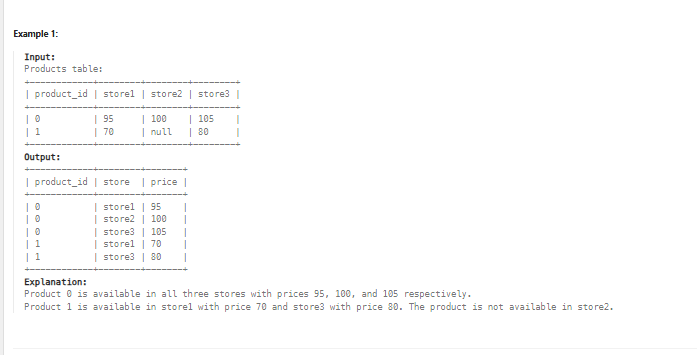

In [44]:
data = [[0, 95, 100, 105], [1, 70, None, 80]]
products = pd.DataFrame(data, columns=['product_id', 'store1', 'store2', 'store3']).astype({'product_id':'Int64', 'store1':'Int64', 'store2':'Int64', 'store3':'Int64'})
products

,product_id,store1,store2,store3
0,0,95,100,105
1,1,70,<NA>,80


In [45]:
products.melt(id_vars = ['product_id'], 
                      value_vars = products.columns[1:],
                        var_name = 'store', 
                      value_name = 'price').dropna()

,product_id,store,price
0,0,store1,95
1,1,store1,70
2,0,store2,100
4,0,store3,105
5,1,store3,80


In [46]:
import pandas as pd

def rearrange_products_table(products: pd.DataFrame) -> pd.DataFrame:
    # Create an empty list to store the rearranged rows
    rearranged_rows = []

    # Iterate over each row in the original table
    for _, row in products.iterrows():
        product_id = row['product_id']

        # Check each store for price availability
        for store_col in ['store1', 'store2', 'store3']:
            price = row[store_col]
            if pd.notna(price):
                # If the price is not null, add the (product_id, store, price) tuple to the list
                rearranged_rows.append((product_id, store_col, price))

    # Create a new DataFrame with the rearranged rows
    result_table = pd.DataFrame(rearranged_rows, columns=['product_id', 'store', 'price'])

    return result_table
    


## 1907. Count Salary Categories

Write a solution to calculate the number of bank accounts for each salary category. The salary categories are:

"Low Salary": All the salaries strictly less than $20000.

"Average Salary": All the salaries in the inclusive range [$20000, $50000].

"High Salary": All the salaries strictly greater than $50000.

The result table must contain all three categories. If there are no accounts in a category, return 0.


Return the result table in any order.

In [47]:
data = [[3, 108939], [2, 12747], [8, 87709], [6, 91796]]
accounts = pd.DataFrame(data, columns=['account_id', 'income']).astype({'account_id':'Int64', 'income':'Int64'})
accounts

,account_id,income
0,3,108939
1,2,12747
2,8,87709
3,6,91796


In [48]:
accounts['category']=accounts['income'].apply(lambda x : "Low Salary" if x<20000 else 
                         ("Average Salary" if (x>=20000  and x<=50000)
                         else "High Salary"))
accounts.groupby(['category']).size().reset_index(name="accounts_count")

,category,accounts_count
0,High Salary,3
1,Low Salary,1


In [49]:
pd.DataFrame({'category': ["Low Salary","Average Salary","High Salary"],
              'accounts_count':[accounts[accounts['income']<20000].shape[0],
              accounts[(accounts['income']>=20000) & (accounts['income']<=50000)].shape[0],
              accounts[accounts['income']>50000].shape[0]                  
              ]})

,category,accounts_count
0,Low Salary,1
1,Average Salary,0
2,High Salary,3


### 1741. Find Total Time Spent by Each Employee

+-------------+------+

| Column Name | Type |

+-------------+------+

| emp_id      | int  |

| event_day   | date |

| in_time     | int  |

| out_time    | int  |

+-------------+------+


(emp_id, event_day, in_time) is the primary key (combinations of columns with unique values) of this table.
The table shows the employees' entries and exits in an office.
event_day is the day at which this event happened, in_time is the minute at which the employee entered the office, and out_time is the minute at which they left the office.
in_time and out_time are between 1 and 1440.
It is guaranteed that no two events on the same day intersect in time, and in_time < out_time.

Write a solution to calculate the total time in minutes spent by each employee on each day at the office. Note that within one day, an employee can enter and leave more than once. The time spent in the office for a single entry is out_time - in_time.

Return the result table in any order.

In [50]:
data = [['1', '2020-11-28', '4', '32'], ['1', '2020-11-28', '55', '200'], ['1', '2020-12-3', '1', '42'], ['2', '2020-11-28', '3', '33'], ['2', '2020-12-9', '47', '74']]
employees = pd.DataFrame(data, columns=['emp_id', 'event_day', 'in_time', 'out_time']).astype({'emp_id':'Int64', 'event_day':'datetime64[ns]', 'in_time':'Int64', 'out_time':'Int64'})

employees

,emp_id,event_day,in_time,out_time
0,1,2020-11-28,4,32
1,1,2020-11-28,55,200
2,1,2020-12-03,1,42
3,2,2020-11-28,3,33
4,2,2020-12-09,47,74


In [51]:


#employees.groupby(['emp_id','event_day']).agg({'in_time':['min'],'out_time':['max']}).reset_index()

In [52]:
employees['time_spent']=employees['out_time']-employees['in_time']
employees

,emp_id,event_day,in_time,out_time,time_spent
0,1,2020-11-28,4,32,28
1,1,2020-11-28,55,200,145
2,1,2020-12-03,1,42,41
3,2,2020-11-28,3,33,30
4,2,2020-12-09,47,74,27


In [53]:
grp=employees.groupby(['emp_id','event_day']).agg({'time_spent':['sum']})
grp.columns=['_'.join(col) for col in grp.columns]
grp=grp.reset_index()
grp=grp.rename(columns={'time_spent_sum':'total_time','event_day':'day' })
grp[['day','emp_id','total_time']] 

,day,emp_id,total_time
0,2020-11-28,1,173
1,2020-12-03,1,41
2,2020-11-28,2,30
3,2020-12-09,2,27


In [54]:
def total_time(employees: pd.DataFrame) -> pd.DataFrame:
    return employees.assign(
        total_time=employees['out_time'] - employees['in_time'],
        day=employees['event_day'].dt.strftime('%Y-%m-%d'),
    ).groupby(
        ['emp_id', 'day'], as_index=False
    )['total_time'].sum()[
        ['day', 'emp_id', 'total_time']
    ]

## 511. Game Play Analysis I
Write a solution to find the first login date for each player.

Return the result table in any order.

The result format is in the following example.

In [55]:
data = [[1, 2, '2016-03-01', 5], [1, 2, '2016-05-02', 6], [2, 3, '2017-06-25', 1], [3, 1, '2016-03-02', 0], [3, 4, '2018-07-03', 5]]
activity = pd.DataFrame(data, columns=['player_id', 'device_id', 'event_date', 'games_played']).astype({'player_id':'Int64', 'device_id':'Int64', 'event_date':'datetime64[ns]', 'games_played':'Int64'})
activity

,player_id,device_id,event_date,games_played
0,1,2,2016-03-01,5
1,1,2,2016-05-02,6
2,2,3,2017-06-25,1
3,3,1,2016-03-02,0
4,3,4,2018-07-03,5


In [56]:
activity['login_rank']=activity.groupby('player_id')['event_date'].rank(method='dense')
activity[activity['login_rank']==1][['player_id','event_date']].rename(columns={'event_date':'first_login'})

,player_id,first_login
0,1,2016-03-01
2,2,2017-06-25
3,3,2016-03-02


In [57]:
##2356. Number of Unique Subjects Taught by Each Teacher
## Write a solution to calculate the number of unique subjects each teacher teaches in the university.




data = [[1, 2, 3], [1, 2, 4], [1, 3, 3], [2, 1, 1], [2, 2, 1], [2, 3, 1], [2, 4, 1]]
teacher = pd.DataFrame(data, columns=['teacher_id', 'subject_id', 'dept_id']).astype({'teacher_id':'Int64', 'subject_id':'Int64', 'dept_id':'Int64'})
teacher

,teacher_id,subject_id,dept_id
0,1,2,3
1,1,2,4
2,1,3,3
3,2,1,1
4,2,2,1
5,2,3,1
6,2,4,1


In [58]:
teacher.groupby(["teacher_id"])['subject_id'].nunique().reset_index(name='cnt')

,teacher_id,cnt
0,1,2
1,2,4


In [59]:
# 596. Classes With at Least 5 Students
# Write a solution to find all the classes that have at least five students.

data = [['A', 'Math'], ['B', 'English'], ['C', 'Math'], ['D', 'Biology'], ['E', 'Math'], ['F', 'Computer'], ['G', 'Math'], ['H', 'Math'], ['I', 'Math']]
courses = pd.DataFrame(data, columns=['student', 'class']).astype({'student':'object', 'class':'object'})

courses

,student,class
0,A,Math
1,B,English
2,C,Math
3,D,Biology
4,E,Math
5,F,Computer
6,G,Math
7,H,Math
8,I,Math


In [60]:
counts=courses['class'].value_counts().reset_index()
counts[counts["count"]>=5]

,class,count
0,Math,6


In [61]:
## 586. Customer Placing the Largest Number of Orders

## Write a solution to find the customer_number for the customer who has placed the largest number of orders.

### The test cases are generated so that exactly one customer will have placed more orders than any other customer.

data = [[1, 1], [2, 2], [3, 3], [4, 3]]
orders = pd.DataFrame(data, columns=['order_number', 'customer_number']).astype({'order_number':'Int64', 'customer_number':'Int64'})
orders

,order_number,customer_number
0,1,1
1,2,2
2,3,3
3,4,3


In [62]:
orders.groupby(['customer_number']).count().reset_index().sort_values(by="order_number",ascending=False)[['customer_number']].head(1)

,customer_number
2,3


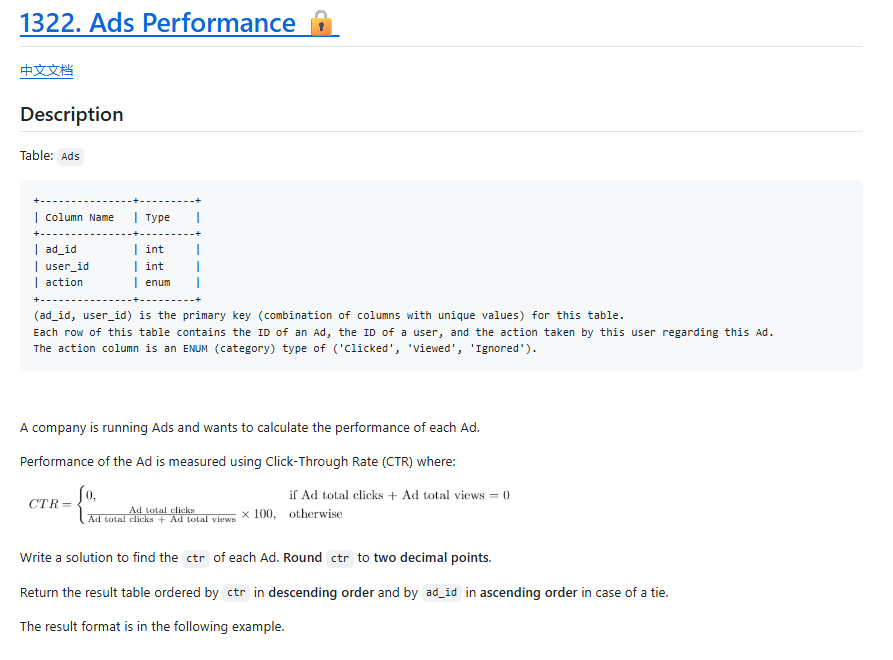

In [63]:
import pandas as pd

# Define the data
data = {
    "ad_id": [1, 2, 3, 5, 1, 2, 3, 1, 2, 1],
    "user_id": [1, 2, 3, 5, 7, 7, 5, 4, 11, 2],
    "action": [
        "Clicked", "Clicked", "Viewed", "Ignored",
        "Ignored", "Viewed", "Clicked", "Viewed",
        "Viewed", "Clicked"
    ]
}

# Create DataFrame
ads_df = pd.DataFrame(data)
ads_df

,ad_id,user_id,action
0,1,1,Clicked
1,2,2,Clicked
2,3,3,Viewed
3,5,5,Ignored
4,1,7,Ignored
5,2,7,Viewed
6,3,5,Clicked
7,1,4,Viewed
8,2,11,Viewed
9,1,2,Clicked


In [64]:
pivot_df = ads_df.pivot_table(
    index="ad_id",
    columns="action",
    aggfunc="size",
    fill_value=0
)
pivot_df

action,Clicked,Ignored,Viewed
ad_id,,,
1,2,1,1
2,1,0,2
3,1,0,1
5,0,1,0


In [65]:

pivot_df['CTR']=round(pivot_df['Clicked']/pivot_df[['Clicked','Viewed']].sum(axis=1) * 100,2)
pivot_df.fillna(0)

action,Clicked,Ignored,Viewed,CTR
ad_id,,,,
1,2,1,1,66.67
2,1,0,2,33.33
3,1,0,1,50.00
5,0,1,0,0.00


In [66]:
##Another way
counts = ads_df.groupby(["ad_id", "action"]).size().unstack(fill_value=0).reset_index()
counts.reset_index(drop=True)
counts.columns

Index(['ad_id', 'Clicked', 'Ignored', 'Viewed'], dtype='str', name='action')

In [67]:
counts['CTR']=round(counts['Clicked']/counts.sum(axis=1) * 100,2)
counts.fillna(0)

action,ad_id,Clicked,Ignored,Viewed,CTR
0,1,2,1,1,40.0
1,2,1,0,2,20.0
2,3,1,0,1,20.0
3,5,0,1,0,0.0


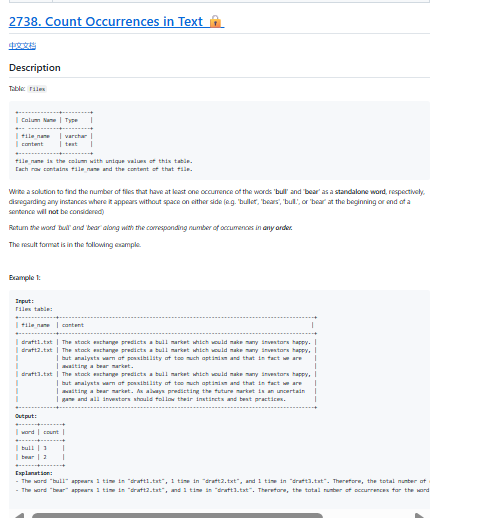

In [68]:
import pandas as pd

data = {
    "file_name": [
        "draft1.txt",
        "draft2.txt",
        "draft3.txt"
    ],
    "content": [
        "The stock exchange predicts a bull market which would make many investors happy.",
        "The stock exchange predicts a bull market which would make many investors happy, but analysts warn of possibility of too much optimism and that in fact we are awaiting a bear market.",
        "The stock exchange predicts a bull market which would make many investors happy, but analysts warn of possibility of too much optimism and that in fact we are awaiting a bear market. As always predicting the future market is an uncertain game and all investors should follow their instincts and best practices."
    ]
}

df = pd.DataFrame(data)

df


,file_name,content
0,draft1.txt,The stock exchange predicts a bull market whic...
1,draft2.txt,The stock exchange predicts a bull market whic...
2,draft3.txt,The stock exchange predicts a bull market whic...


In [69]:
# Write a solution to find the number of files that have at least one occurrence of the words 'bull' and 'bear'
#  as a standalone word, respectively, disregarding any instances where it appears without space on either side 
# (e.g. 'bullet', 'bears', 'bull.', or 'bear' at the beginning or end of a sentence will not be considered) 

# Return the word 'bull' and 'bear' along with the corresponding number of occurrences in any order.

In [70]:
df['bull']= df['content'].apply(lambda x: x.count('bull'))
df['bear']= df['content'].apply(lambda x: x.count('bear'))


In [71]:
df

,file_name,content,bull,bear
0,draft1.txt,The stock exchange predicts a bull market whic...,1,0
1,draft2.txt,The stock exchange predicts a bull market whic...,1,1
2,draft3.txt,The stock exchange predicts a bull market whic...,1,1


In [72]:
df[['bull','bear']].T.sum(axis=1).reset_index(name='count').rename(columns={'index':"word"})

,word,count
0,bull,3
1,bear,2


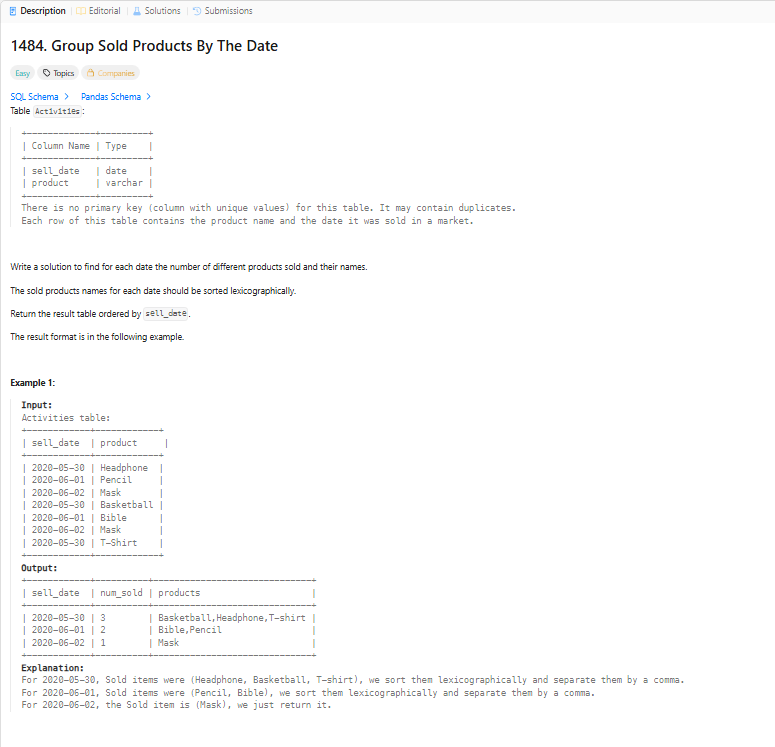

In [73]:
data = [['2020-05-30', 'Headphone'], ['2020-06-01', 'Pencil'], ['2020-06-02', 'Mask'], ['2020-05-30', 'Basketball'], ['2020-06-01', 'Bible'], ['2020-06-02', 'Mask'], ['2020-05-30', 'T-Shirt']]
activities = pd.DataFrame(data, columns=['sell_date', 'product']).astype({'sell_date':'datetime64[ns]', 'product':'object'})
activities

,sell_date,product
0,2020-05-30,Headphone
1,2020-06-01,Pencil
2,2020-06-02,Mask
3,2020-05-30,Basketball
4,2020-06-01,Bible
5,2020-06-02,Mask
6,2020-05-30,T-Shirt


In [74]:
numsolds=activities.groupby(['sell_date']).size().reset_index(name="num_sold ")
numsolds

,sell_date,num_sold
0,2020-05-30,3
1,2020-06-01,2
2,2020-06-02,2


In [75]:
product_names=activities.groupby(['sell_date'])['product'].apply(lambda x : ','.join(sorted([i for i in set(x)]))).reset_index(name="products")
product_names

,sell_date,products
0,2020-05-30,"Basketball,Headphone,T-Shirt"
1,2020-06-01,"Bible,Pencil"
2,2020-06-02,Mask


In [76]:
product_names.merge(numsolds,left_on='sell_date',right_on='sell_date', how='inner')

,sell_date,products,num_sold
0,2020-05-30,"Basketball,Headphone,T-Shirt",3
1,2020-06-01,"Bible,Pencil",2
2,2020-06-02,Mask,2


In [77]:
###Its not right i need to return the unique product counts
product_names=activities.groupby(['sell_date'])['product'].apply(lambda x : ','.join(sorted([i for i in set(x)]))).reset_index(name="products")
product_names['num_sold']=product_names["products"].apply(lambda x: len(x.split(",")))
product_names.sort_values(by=['sell_date']).reset_index(drop=True)
product_names[['sell_date','num_sold','products']]

,sell_date,num_sold,products
0,2020-05-30,3,"Basketball,Headphone,T-Shirt"
1,2020-06-01,2,"Bible,Pencil"
2,2020-06-02,1,Mask


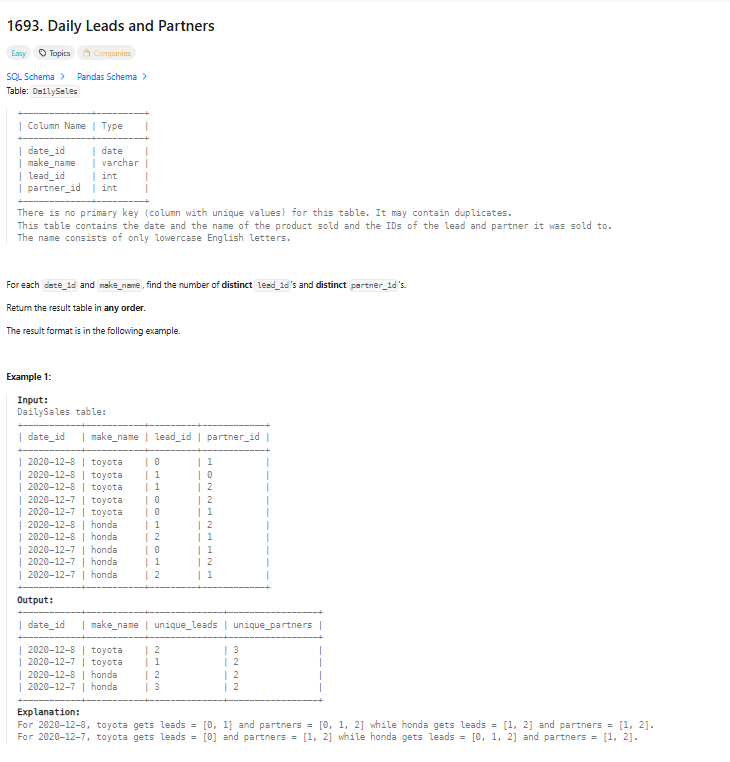

In [78]:
data = [['2020-12-8', 'toyota', 0, 1], ['2020-12-8', 'toyota', 1, 0], ['2020-12-8', 'toyota', 1, 2], ['2020-12-7', 'toyota', 0, 2], ['2020-12-7', 'toyota', 0, 1], ['2020-12-8', 'honda', 1, 2], ['2020-12-8', 'honda', 2, 1], ['2020-12-7', 'honda', 0, 1], ['2020-12-7', 'honda', 1, 2], ['2020-12-7', 'honda', 2, 1]]
daily_sales = pd.DataFrame(data, columns=['date_id', 'make_name', 'lead_id', 'partner_id']).astype({'date_id':'datetime64[ns]', 'make_name':'object', 'lead_id':'Int64', 'partner_id':'Int64'})
daily_sales

,date_id,make_name,lead_id,partner_id
0,2020-12-08,toyota,0,1
1,2020-12-08,toyota,1,0
2,2020-12-08,toyota,1,2
3,2020-12-07,toyota,0,2
4,2020-12-07,toyota,0,1
5,2020-12-08,honda,1,2
6,2020-12-08,honda,2,1
7,2020-12-07,honda,0,1
8,2020-12-07,honda,1,2
9,2020-12-07,honda,2,1


In [79]:
## For each date_id and make_name, find the number of distinct lead_id's and distinct partner_id's.Return the result table in any order.

grouped =daily_sales.groupby(['date_id', 'make_name']).agg(['nunique']).reset_index()
grouped.columns=(['_'.join(col) for col in grouped.columns])
grouped

,date_id_,make_name_,lead_id_nunique,partner_id_nunique
0,2020-12-07,honda,3,2
1,2020-12-07,toyota,1,2
2,2020-12-08,honda,2,2
3,2020-12-08,toyota,2,3


In [80]:
##Grouping with renaming
grouped =daily_sales.groupby(['date_id', 'make_name']).agg(unique_leads= ('lead_id','nunique'),unique_partners = ('partner_id','nunique')).reset_index()
grouped

,date_id,make_name,unique_leads,unique_partners
0,2020-12-07,honda,3,2
1,2020-12-07,toyota,1,2
2,2020-12-08,honda,2,2
3,2020-12-08,toyota,2,3


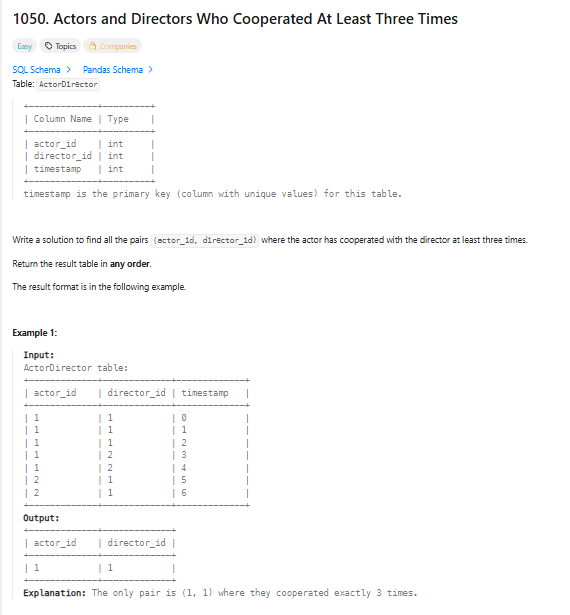

In [81]:
data = [[1, 1, 0], [1, 1, 1], [1, 1, 2], [1, 2, 3], [1, 2, 4], [2, 1, 5], [2, 1, 6]]
actor_director = pd.DataFrame(data, columns=['actor_id', 'director_id', 'timestamp']).astype({'actor_id':'int64', 'director_id':'int64', 'timestamp':'int64'})
actor_director

,actor_id,director_id,timestamp
0,1,1,0
1,1,1,1
2,1,1,2
3,1,2,3
4,1,2,4
5,2,1,5
6,2,1,6


In [82]:
##Write a solution to find all the pairs (actor_id, director_id) where the actor has cooperated with the director at least three times.

#using loc
actor_director.groupby(['actor_id', 'director_id']).size().reset_index(name='count').loc[lambda x: x['count']>=3 ]



,actor_id,director_id,count
0,1,1,3


### Option 1: Use .query() (Cleanest for method chains)
###  The .query() method allows you to pass a string condition directly:

In [83]:

actor_director.groupby(['actor_id', 'director_id']).size().reset_index(name='count').query('count >= 3')[['actor_id', 'director_id']]

,actor_id,director_id
0,1,1


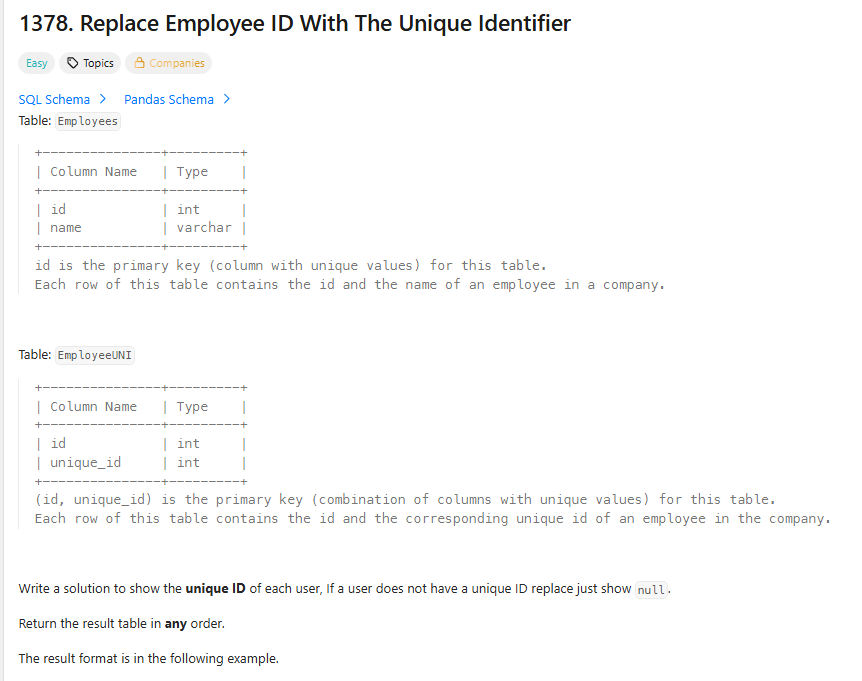


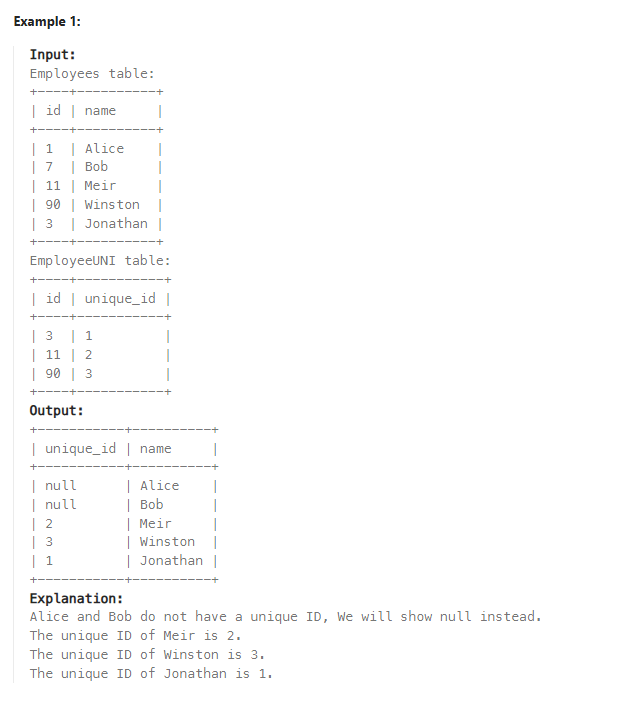

In [84]:
data = [[1, 'Alice'], [7, 'Bob'], [11, 'Meir'], [90, 'Winston'], [3, 'Jonathan']]
employees = pd.DataFrame(data, columns=['id', 'name']).astype({'id':'int64', 'name':'object'})
data = [[3, 1], [11, 2], [90, 3]]
employee_uni = pd.DataFrame(data, columns=['id', 'unique_id']).astype({'id':'int64', 'unique_id':'int64'})

In [85]:
employees

,id,name
0,1,Alice
1,7,Bob
2,11,Meir
3,90,Winston
4,3,Jonathan


In [86]:
employee_uni

,id,unique_id
0,3,1
1,11,2
2,90,3


In [87]:
employees.merge(employee_uni,on='id',how='left')[['unique_id','name']]

,unique_id,name
0,NaN,Alice
1,NaN,Bob
2,2.0,Meir
3,3.0,Winston
4,1.0,Jonathan


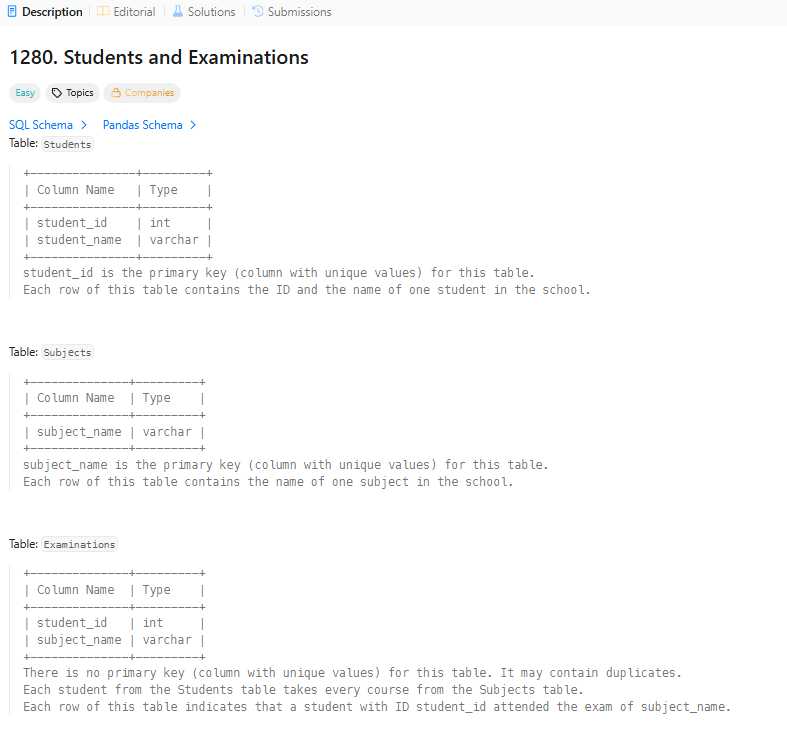



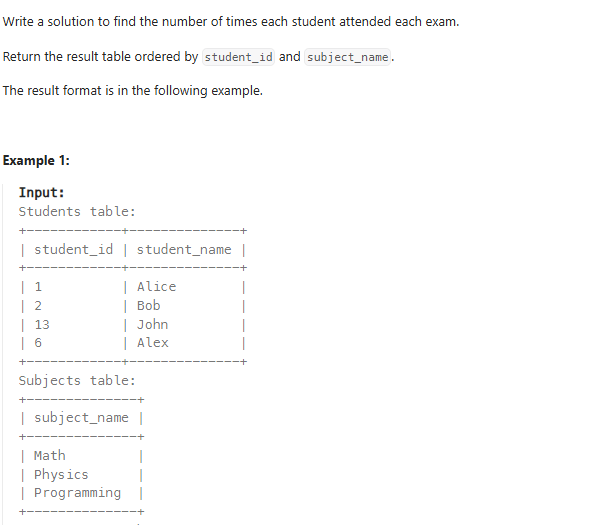

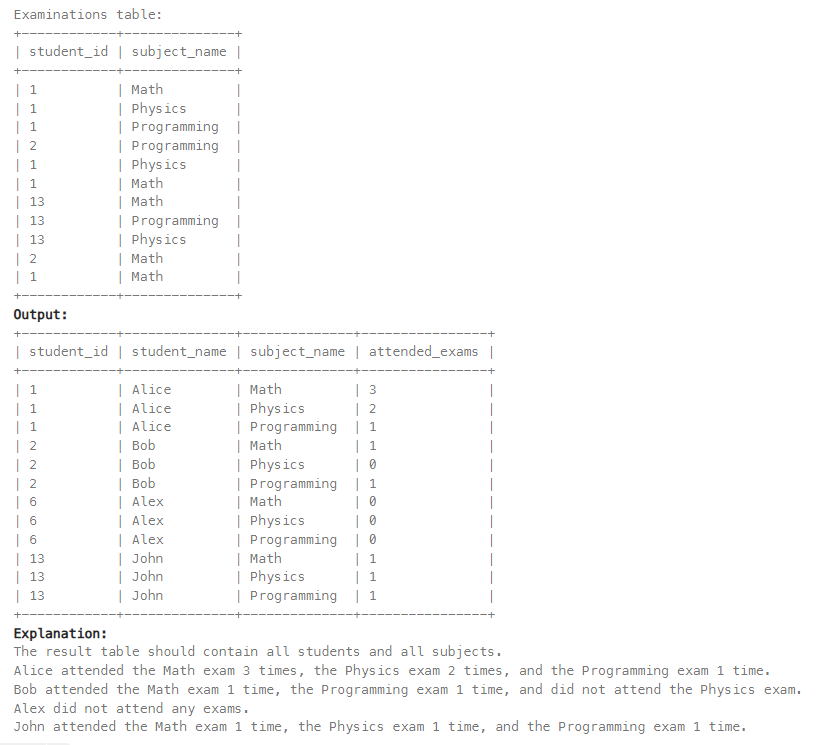


In [88]:
data = [[1, 'Alice'], [2, 'Bob'], [13, 'John'], [6, 'Alex']]
students = pd.DataFrame(data, columns=['student_id', 'student_name']).astype({'student_id':'Int64', 'student_name':'object'})
data = [['Math'], ['Physics'], ['Programming']]
subjects = pd.DataFrame(data, columns=['subject_name']).astype({'subject_name':'object'})
data = [[1, 'Math'], [1, 'Physics'], [1, 'Programming'], [2, 'Programming'], [1, 'Physics'], [1, 'Math'], [13, 'Math'], [13, 'Programming'], [13, 'Physics'], [2, 'Math'], [1, 'Math']]
examinations = pd.DataFrame(data, columns=['student_id', 'subject_name']).astype({'student_id':'Int64', 'subject_name':'object'})

In [89]:
# Write a solution to find the number of times each student attended each exam.

# Return the result table ordered by student_id and subject_name.

# The result format is in the following example.

In [90]:
students_subject=students.merge(subjects,how='cross')
students_subject

,student_id,student_name,subject_name
0,1,Alice,Math
1,1,Alice,Physics
2,1,Alice,Programming
3,2,Bob,Math
4,2,Bob,Physics
5,2,Bob,Programming
6,13,John,Math
7,13,John,Physics
8,13,John,Programming
9,6,Alex,Math


In [91]:
exams_counts=examinations.groupby(['student_id', 'subject_name']).size().reset_index(name='attended_exams')
exams_counts

,student_id,subject_name,attended_exams
0,1,Math,3
1,1,Physics,2
2,1,Programming,1
3,2,Math,1
4,2,Programming,1
5,13,Math,1
6,13,Physics,1
7,13,Programming,1


In [92]:
exams_counts.merge(students_subject,on=['student_id','subject_name'],how="right").fillna({"attended_exams":0}).sort_values(by=['student_id','subject_name'])[['student_id', 'student_name', 'subject_name', 'attended_exams']].reset_index(drop=True)

,student_id,student_name,subject_name,attended_exams
0,1,Alice,Math,3.0
1,1,Alice,Physics,2.0
2,1,Alice,Programming,1.0
3,2,Bob,Math,1.0
4,2,Bob,Physics,0.0
5,2,Bob,Programming,1.0
6,6,Alex,Math,0.0
7,6,Alex,Physics,0.0
8,6,Alex,Programming,0.0
9,13,John,Math,1.0


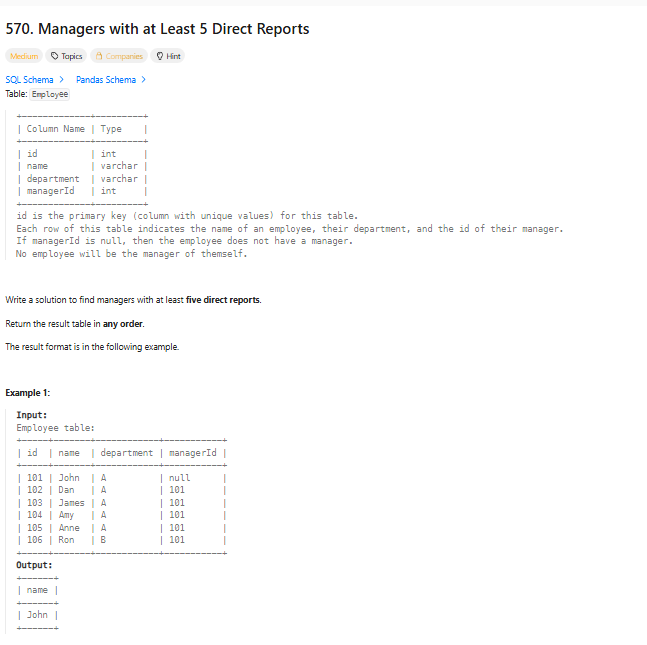

In [93]:
data = [[101, 'John', 'A', None], [102, 'Dan', 'A', 101], [103, 'James', 'A', 101], [104, 'Amy', 'A', 101], [105, 'Anne', 'A', 101], [106, 'Ron', 'B', 101]]
employee = pd.DataFrame(data, columns=['id', 'name', 'department', 'managerId']).astype({'id':'Int64', 'name':'object', 'department':'object', 'managerId':'Int64'})

employee

,id,name,department,managerId
0,101,John,A,<NA>
1,102,Dan,A,101
2,103,James,A,101
3,104,Amy,A,101
4,105,Anne,A,101
5,106,Ron,B,101


In [94]:
import pandas as pd

employee = pd.DataFrame({
    'id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111],
    'name': ['John', 'Dan', 'James', 'Amy', 'Anne', 'Ron', 'Tom', 'Tommy', 'Peter', 'Dong', 'DIDI'],
    'department': ['A', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'C', 'A', 'D'],
    'managerId': [None, 101, 101, 101, 101, 101, 102, 102, 102, 102, 102]
})
employee['managerId'] = employee['managerId'].astype('Int64')
employee

,id,name,department,managerId
0,101,John,A,<NA>
1,102,Dan,A,101
2,103,James,A,101
3,104,Amy,A,101
4,105,Anne,A,101
5,106,Ron,B,101
6,107,Tom,A,102
7,108,Tommy,A,102
8,109,Peter,C,102
9,110,Dong,A,102


In [95]:
mangers=employee[employee['id'].isin( employee['managerId'].unique())]
mangers

,id,name,department,managerId
0,101,John,A,<NA>
1,102,Dan,A,101


In [96]:
mangers_counts=employee.groupby(['managerId']).size().reset_index(name="reportees_count")
mangers_counts

,managerId,reportees_count
0,101,5
1,102,5


In [97]:
mangers.merge(mangers_counts,left_on="id",right_on="managerId",how="left").loc[lambda x: x['reportees_count']>=5 ,['name']]

,name
0,John
1,Dan


In [98]:
data = [[1, 'John', 100000, 6, '4/1/2006'], [2, 'Amy', 12000, 5, '5/1/2010'], [3, 'Mark', 65000, 12, '12/25/2008'], [4, 'Pam', 25000, 25, '1/1/2005'], [5, 'Alex', 5000, 10, '2/3/2007']]
sales_person = pd.DataFrame(data, columns=['sales_id', 'name', 'salary', 'commission_rate', 'hire_date']).astype({'sales_id':'Int64', 'name':'object', 'salary':'Int64', 'commission_rate':'Int64', 'hire_date':'datetime64[ns]'})
data = [[1, 'RED', 'Boston'], [2, 'ORANGE', 'New York'], [3, 'YELLOW', 'Boston'], [4, 'GREEN', 'Austin']]
company = pd.DataFrame(data, columns=['com_id', 'name', 'city']).astype({'com_id':'Int64', 'name':'object', 'city':'object'})
data = [[1, '1/1/2014', 3, 4, 10000], [2, '2/1/2014', 4, 5, 5000], [3, '3/1/2014', 1, 1, 50000], [4, '4/1/2014', 1, 4, 25000]]
orders = pd.DataFrame(data, columns=['order_id', 'order_date', 'com_id', 'sales_id', 'amount']).astype({'order_id':'Int64', 'order_date':'datetime64[ns]', 'com_id':'Int64', 'sales_id':'Int64', 'amount':'Int64'})


In [99]:
sales_person

,sales_id,name,salary,commission_rate,hire_date
0,1,John,100000,6,2006-04-01
1,2,Amy,12000,5,2010-05-01
2,3,Mark,65000,12,2008-12-25
3,4,Pam,25000,25,2005-01-01
4,5,Alex,5000,10,2007-02-03


In [100]:
company

,com_id,name,city
0,1,RED,Boston
1,2,ORANGE,New York
2,3,YELLOW,Boston
3,4,GREEN,Austin


In [101]:
orders

,order_id,order_date,com_id,sales_id,amount
0,1,2014-01-01,3,4,10000
1,2,2014-02-01,4,5,5000
2,3,2014-03-01,1,1,50000
3,4,2014-04-01,1,4,25000


Write a solution to find the names of all the salespersons who did not have any orders related to the company with the name "RED".

Return the result table in any order.

The result format is in the following example.

In [102]:
sales_person[~sales_person['sales_id'].isin((orders[orders['com_id'].isin ((company[company['name']=="RED"]['com_id'].values))]['sales_id'].values))][['name']]

,name
1,Amy
2,Mark
4,Alex


In [103]:
type(lambda x: x+10)

function

## 2041. Accepted Candidates From the Interviews 🔒
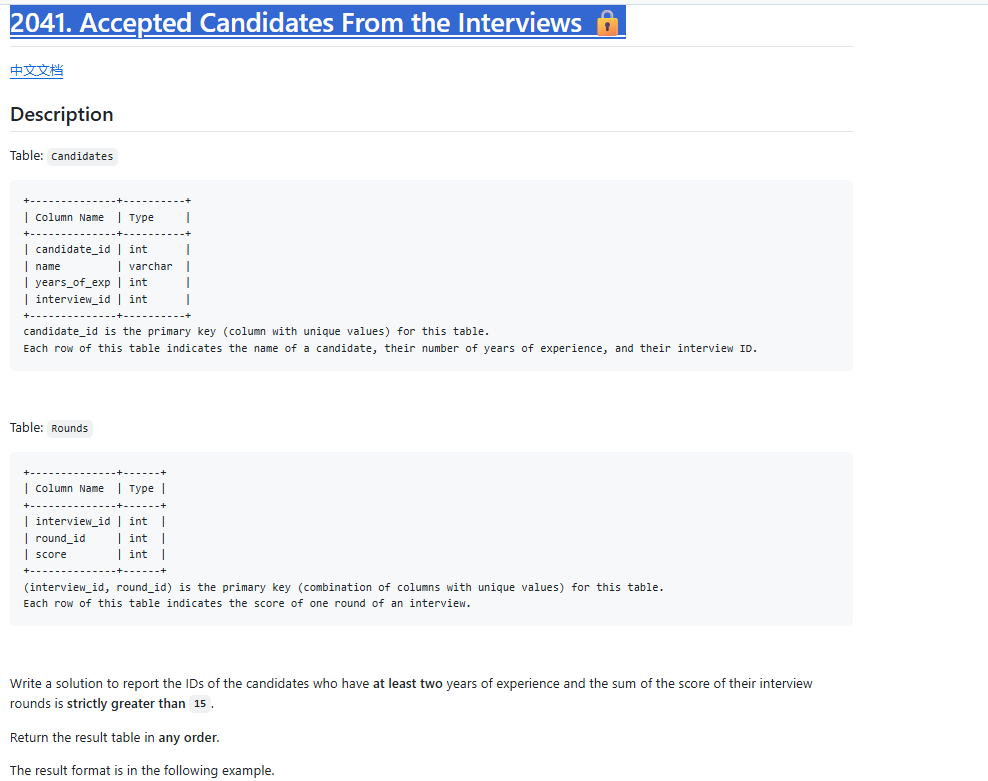
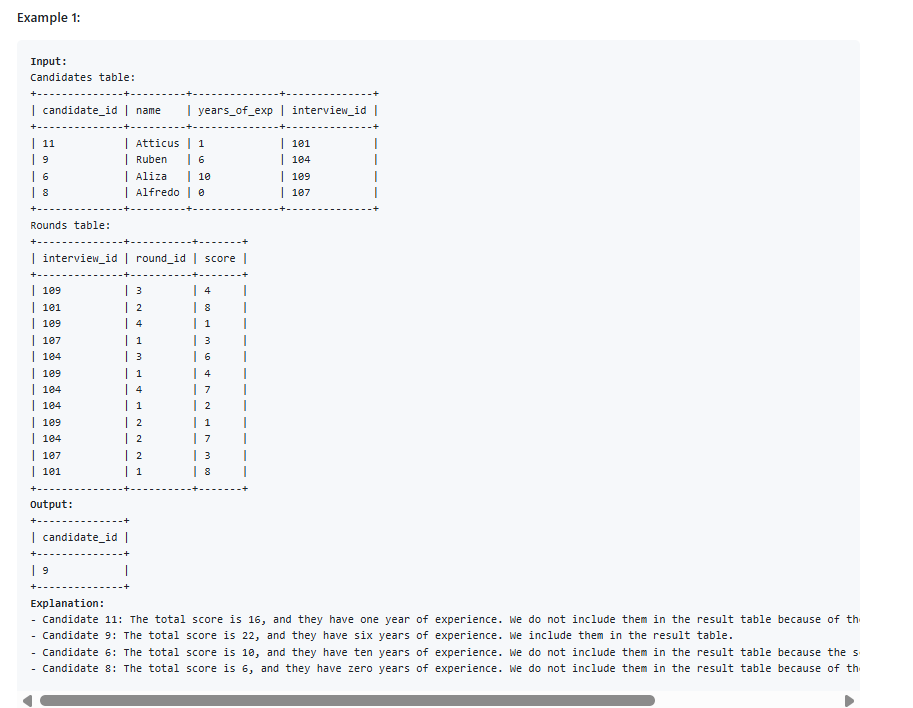


In [104]:
import pandas as pd

candidates = pd.DataFrame({
    "candidate_id": [11, 9, 6, 8],
    "name": ["Atticus", "Ruben", "Aliza", "Alfredo"],
    "years_of_exp": [1, 6, 10, 0],
    "interview_id": [101, 104, 109, 107]
})

rounds = pd.DataFrame({
    "interview_id": [109, 101, 109, 107, 104, 109, 104, 104, 109, 104, 107, 101],
    "round_id": [3, 2, 4, 1, 3, 1, 4, 1, 2, 2, 2, 1],
    "score": [4, 8, 1, 3, 6, 4, 7, 2, 1, 7, 3, 8]
})

candidates 


,candidate_id,name,years_of_exp,interview_id
0,11,Atticus,1,101
1,9,Ruben,6,104
2,6,Aliza,10,109
3,8,Alfredo,0,107


In [105]:
rounds

,interview_id,round_id,score
0,109,3,4
1,101,2,8
2,109,4,1
3,107,1,3
4,104,3,6
5,109,1,4
6,104,4,7
7,104,1,2
8,109,2,1
9,104,2,7


In [106]:
# Write a solution to report the IDs of the candidates who have at least two years of experience and the sum of the score of their interview rounds is strictly greater than 15.

# Return the result table in any order.

# The result format is in the following example.

 

In [107]:
filter_candiates=candidates[candidates['years_of_exp']>=2]
filter_candiates

,candidate_id,name,years_of_exp,interview_id
1,9,Ruben,6,104
2,6,Aliza,10,109


In [108]:
total_scores=rounds.groupby(['interview_id']).sum().reset_index().loc[lambda x:x['score']>15]
total_scores

,interview_id,round_id,score
0,101,3,16
1,104,10,22


In [109]:
filter_candiates.merge(total_scores,on='interview_id',how='left').loc[lambda x: ~x['score'].isna()][['candidate_id']]

,candidate_id
0,9
